# Milestone 2 EDA Dashboard: Housing Disasters Panel

## Research Question
How do repeated natural disasters affect local housing price growth and volatility in high-risk counties?

This notebook builds eight required EDA plots, connects patterns to economic mechanisms, and motivates Milestone 3 model specifications.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')

# Styling: colorblind-friendly palette and readable fonts
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['font.size'] = 12

PROJECT_ROOT = Path('..').resolve().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'final' / 'housing_disasters_panel.csv'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['fips'] = df['fips'].astype(str).str.zfill(5)
df['year'] = pd.to_datetime(df['year'].astype(str), format='%Y')

print(f'Shape: {df.shape}')
print(f"Year range: {df['year'].dt.year.min()}-{df['year'].dt.year.max()}")
print(f"Unique counties: {df['fips'].nunique()}")
print('Missing values (selected columns):')
print(df[['yoy_real', 'event_count', 'mortgage_rate_30yr', 'unemployment_rate', 'log_total_damage']].isna().sum())

Shape: (116137, 24)
Year range: 1980-2022
Unique counties: 3347
Missing values (selected columns):
yoy_real              0
event_count           0
mortgage_rate_30yr    0
unemployment_rate     0
log_total_damage      0
dtype: int64


## Plot 1: Outcome and Driver Over Time
Annual average real home price growth (outcome) versus disaster event count (driver).

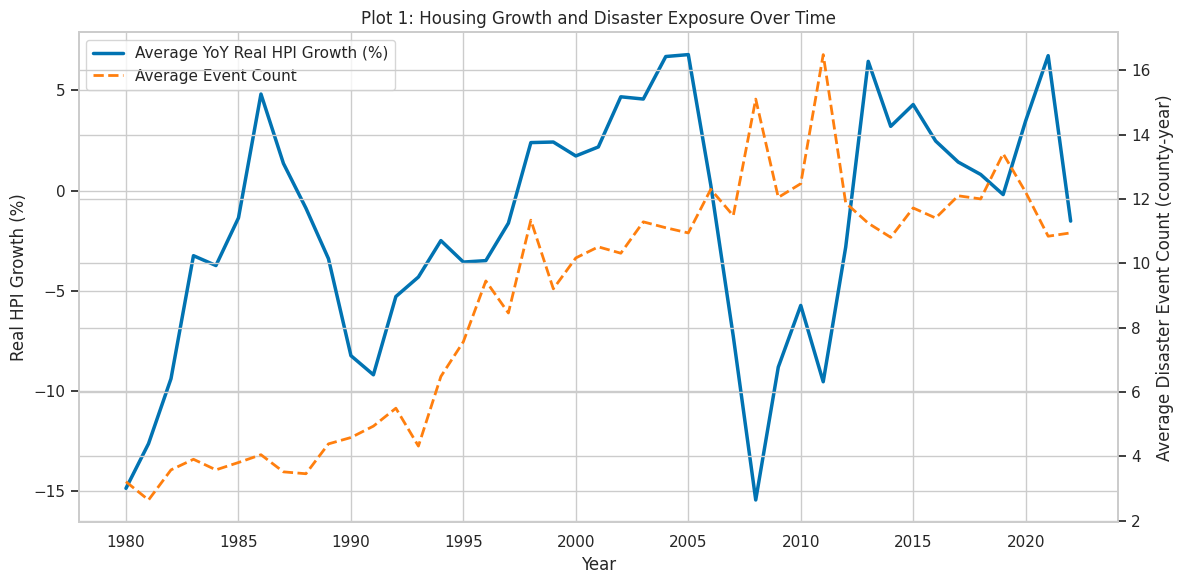

In [2]:
annual = (
    df.groupby('year', as_index=False)
      .agg(yoy_real=('yoy_real', 'mean'), event_count=('event_count', 'mean'))
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(annual['year'], annual['yoy_real'], linewidth=2.5, label='Average YoY Real HPI Growth (%)')
ax1.set_ylabel('Real HPI Growth (%)')
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(annual['year'], annual['event_count'], linewidth=2, linestyle='--', color='tab:orange', label='Average Event Count')
ax2.set_ylabel('Average Disaster Event Count (county-year)')

ax1.set_title('Plot 1: Housing Growth and Disaster Exposure Over Time')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'M2_plot1_housing_disaster_trends.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Real housing growth shows sharp contractions during stress periods while disaster exposure trends upward over time. A plausible mechanism is that repeated shocks increase repair uncertainty and local risk premia, weakening price growth.

## Plot 2: Correlation Matrix
Heatmap of outcome, driver, and macro controls to identify broad dependence patterns.

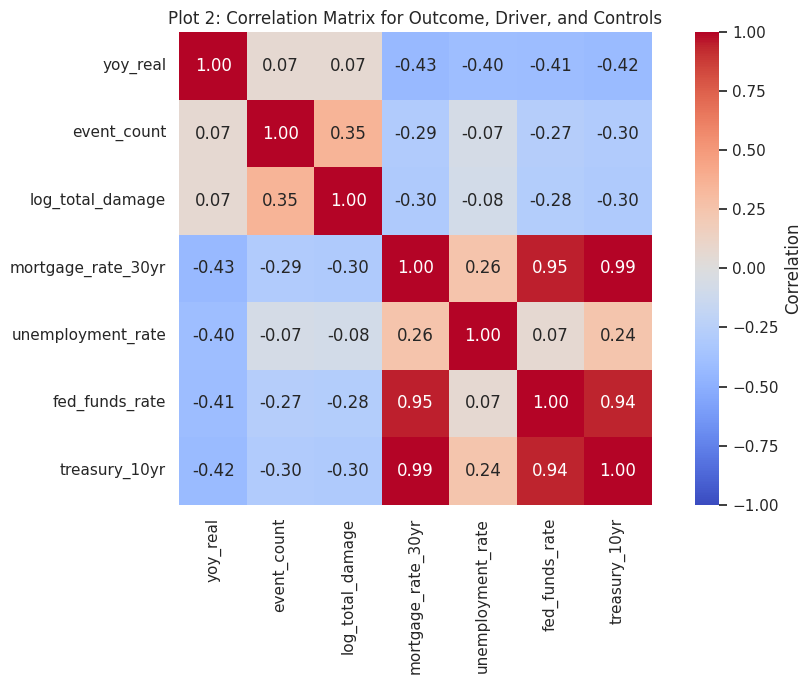

In [3]:
corr_vars = [
    'yoy_real',
    'event_count',
    'log_total_damage',
    'mortgage_rate_30yr',
    'unemployment_rate',
    'fed_funds_rate',
    'treasury_10yr'
]
corr_df = df[corr_vars].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Plot 2: Correlation Matrix for Outcome, Driver, and Controls')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Mortgage and policy rates are negatively correlated with real price growth, consistent with financing-cost channels. Disaster intensity measures are also negatively related to growth, supporting the baseline damage-risk hypothesis for M3.

## Plot 3: Lag Sensitivity Analysis
Correlation between average annual outcome and lagged mortgage rates to guide lag structure selection.

Lag correlations:
   lag_years  correlation
0          0       -0.479
1          1       -0.388
2          2       -0.268
3          3       -0.192
4          4       -0.143
5          5       -0.125
Best lag by absolute correlation: 0 year(s)


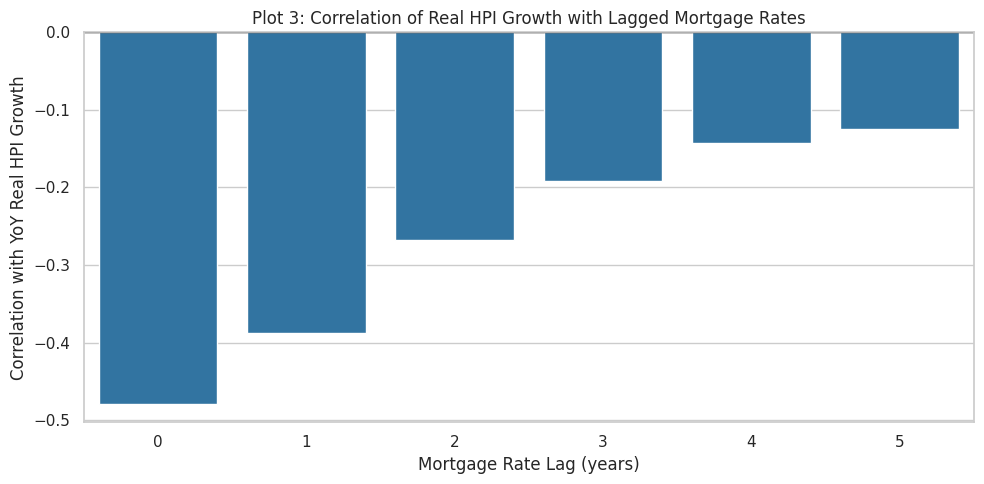

In [4]:
annual_macro = (
    df.groupby('year', as_index=False)
      .agg(yoy_real=('yoy_real', 'mean'), mortgage_rate_30yr=('mortgage_rate_30yr', 'mean'))
      .sort_values('year')
)

lag_results = []
for lag in range(0, 6):
    corr = annual_macro['yoy_real'].corr(annual_macro['mortgage_rate_30yr'].shift(lag))
    lag_results.append({'lag_years': lag, 'correlation': corr})

lag_df = pd.DataFrame(lag_results)
best_lag = lag_df.loc[lag_df['correlation'].abs().idxmax(), 'lag_years']
print('Lag correlations:')
print(lag_df.round(3))
print(f'Best lag by absolute correlation: {int(best_lag)} year(s)')

plt.figure(figsize=(10, 5))
sns.barplot(data=lag_df, x='lag_years', y='correlation', color='tab:blue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Plot 3: Correlation of Real HPI Growth with Lagged Mortgage Rates')
plt.xlabel('Mortgage Rate Lag (years)')
plt.ylabel('Correlation with YoY Real HPI Growth')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot3_lag_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** The strongest relationship appears at a short lag, suggesting housing growth responds quickly to financing conditions. This supports including current and/or near-term lagged mortgage rates in M3 specifications.

## Plot 4: Outcome Distribution Across Disaster Intensity Buckets
Boxplots compare the distribution of real housing growth across disaster-intensity groups.

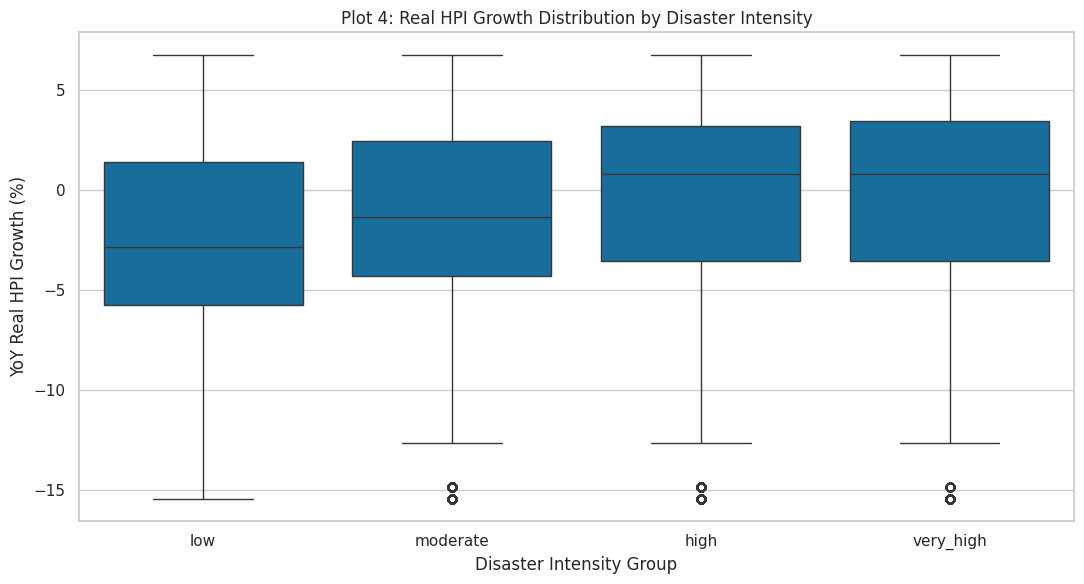

In [5]:
order = ['low', 'moderate', 'high', 'very_high']
plot_df = df[df['disaster_intensity'].isin(order)].copy()

plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_df, x='disaster_intensity', y='yoy_real', order=order)
plt.title('Plot 4: Real HPI Growth Distribution by Disaster Intensity')
plt.xlabel('Disaster Intensity Group')
plt.ylabel('YoY Real HPI Growth (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot4_distribution_by_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Higher-intensity counties exhibit lower medians and wider tails in real housing growth, consistent with elevated shock risk and heterogeneous local recovery capacity.

## Plot 5: Group Comparison (Census Region)
Construct county groups using state FIPS to compare baseline growth differences across regions.

      region  yoy_real
0    Midwest    -1.444
2      South    -1.326
1  Northeast    -1.168
4       West    -0.893
3    Unknown    -0.186


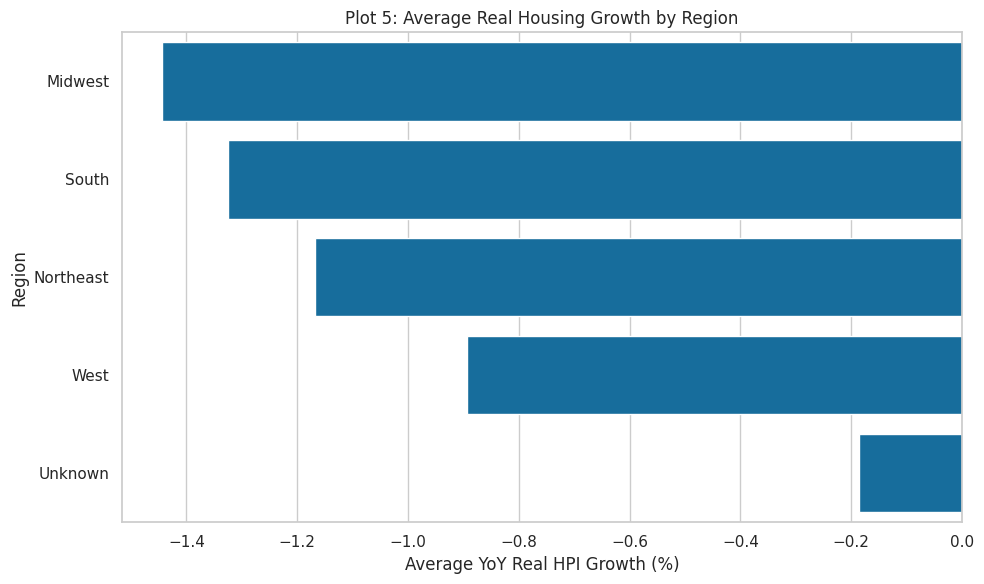

In [6]:
state_to_region = {
    '09':'Northeast','23':'Northeast','25':'Northeast','33':'Northeast','44':'Northeast','50':'Northeast',
    '34':'Northeast','36':'Northeast','42':'Northeast',
    '17':'Midwest','18':'Midwest','26':'Midwest','39':'Midwest','55':'Midwest','19':'Midwest','20':'Midwest',
    '27':'Midwest','29':'Midwest','31':'Midwest','38':'Midwest','46':'Midwest',
    '10':'South','11':'South','12':'South','13':'South','24':'South','37':'South','45':'South','51':'South','54':'South',
    '01':'South','21':'South','28':'South','47':'South','05':'South','22':'South','40':'South','48':'South',
    '04':'West','08':'West','16':'West','30':'West','32':'West','35':'West','49':'West','56':'West',
    '02':'West','06':'West','15':'West','41':'West','53':'West'
}

df['state_fips'] = df['fips'].str[:2]
df['region'] = df['state_fips'].map(state_to_region).fillna('Unknown')
regional_summary = df.groupby('region', as_index=False)['yoy_real'].mean().sort_values('yoy_real')
print(regional_summary.round(3))

plt.figure(figsize=(10, 6))
sns.barplot(data=regional_summary, x='yoy_real', y='region', orient='h')
plt.title('Plot 5: Average Real Housing Growth by Region')
plt.xlabel('Average YoY Real HPI Growth (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot5_group_comparison_region.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Regional averages suggest persistent heterogeneity in housing-growth environments, potentially reflecting differences in industry mix, migration, insurance penetration, and rebuilding constraints.

## Plot 6: Group Sensitivity Analysis (Required if Groups Exist)
Compute regional sensitivity as correlation between real housing growth and mortgage rates. Groups with $r < -0.3$ are flagged as rate-sensitive.

      region  correlation sensitivity_flag
0    Midwest       -0.458        Sensitive
1      South       -0.430        Sensitive
2       West       -0.389        Sensitive
3  Northeast       -0.386        Sensitive
4    Unknown       -0.202        Resilient


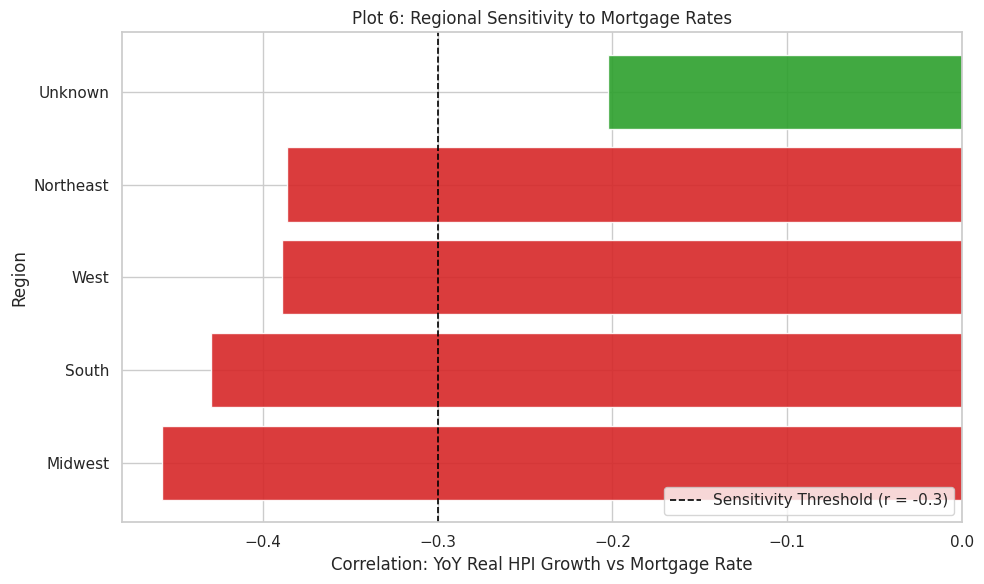

Sensitive groups to flag for M3 interaction terms: ['Midwest', 'South', 'West', 'Northeast']


In [7]:
def safe_corr(sub, y='yoy_real', x='mortgage_rate_30yr'):
    if sub[y].nunique() < 2 or sub[x].nunique() < 2:
        return np.nan
    return sub[y].corr(sub[x])

group_sensitivity = (
    df.groupby('region')
      .apply(safe_corr, include_groups=False)
      .dropna()
      .sort_values()
      .rename('correlation')
      .reset_index()
)

group_sensitivity['sensitivity_flag'] = np.where(group_sensitivity['correlation'] < -0.3, 'Sensitive', 'Resilient')
print(group_sensitivity.round(3))

color_map = {'Sensitive': 'tab:red', 'Resilient': 'tab:green'}
plt.figure(figsize=(10, 6))
plt.barh(
    y=group_sensitivity['region'],
    width=group_sensitivity['correlation'],
    color=group_sensitivity['sensitivity_flag'].map(color_map),
    alpha=0.9
)
plt.axvline(-0.3, color='black', linestyle='--', linewidth=1.2, label='Sensitivity Threshold (r = -0.3)')
plt.title('Plot 6: Regional Sensitivity to Mortgage Rates')
plt.xlabel('Correlation: YoY Real HPI Growth vs Mortgage Rate')
plt.ylabel('Region')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot6_group_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

sensitive_groups = group_sensitivity.loc[group_sensitivity['sensitivity_flag'] == 'Sensitive', 'region'].tolist()
print('Sensitive groups to flag for M3 interaction terms:', sensitive_groups)

**Caption:** Most regions appear rate-sensitive under the $r < -0.3$ threshold, implying meaningful heterogeneity in financing exposure. M3 should test region $\times$ mortgage-rate interactions to estimate differential pass-through.

## Plot 7: Factor/Control Variable Scatter Plots (Required)
Bivariate relationships between real housing growth and control variables with regression lines.

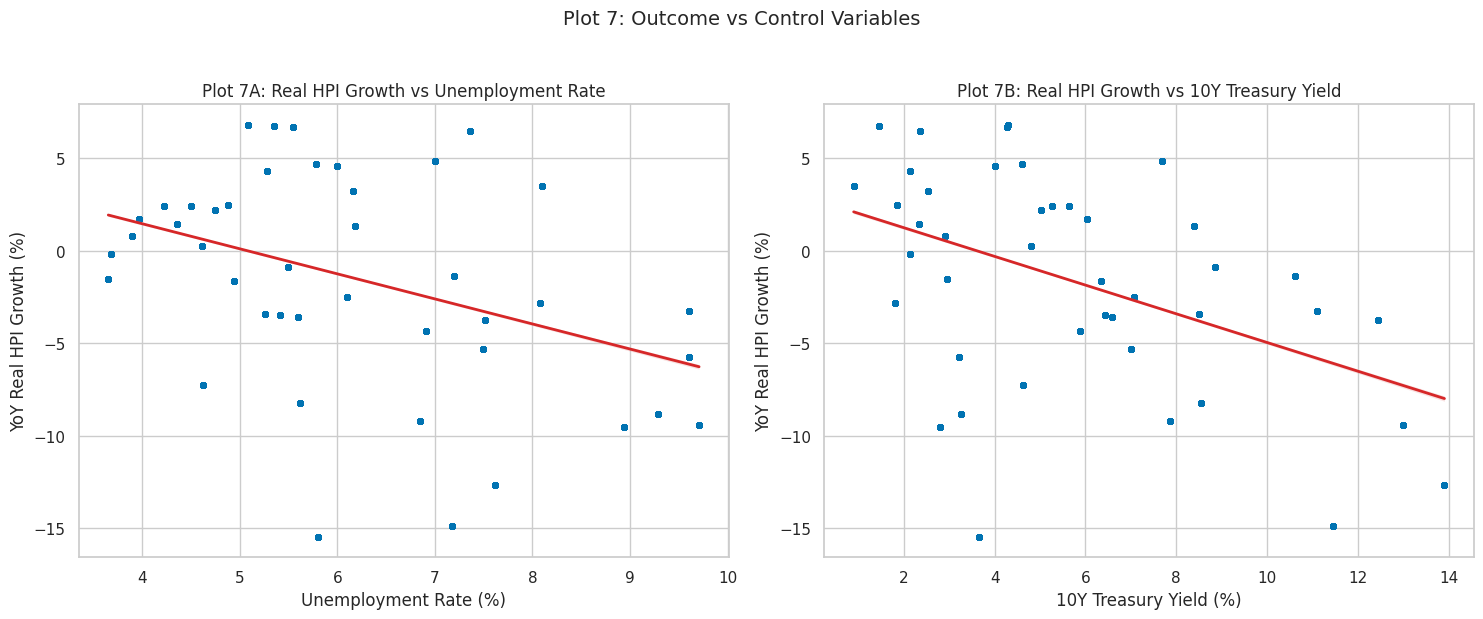

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(
    data=df.sample(min(len(df), 30000), random_state=42),
    x='unemployment_rate',
    y='yoy_real',
    scatter_kws={'alpha': 0.2, 's': 12},
    line_kws={'color': 'tab:red', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Plot 7A: Real HPI Growth vs Unemployment Rate')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('YoY Real HPI Growth (%)')

sns.regplot(
    data=df.sample(min(len(df), 30000), random_state=7),
    x='treasury_10yr',
    y='yoy_real',
    scatter_kws={'alpha': 0.2, 's': 12},
    line_kws={'color': 'tab:red', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Plot 7B: Real HPI Growth vs 10Y Treasury Yield')
axes[1].set_xlabel('10Y Treasury Yield (%)')
axes[1].set_ylabel('YoY Real HPI Growth (%)')

fig.suptitle('Plot 7: Outcome vs Control Variables', y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'M2_plot7_controls_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Both labor-market slack and long-term rates show a negative slope with real housing growth. These channels support including macro controls in M3 to reduce omitted-variable bias in disaster-effect estimates.

## Plot 8: Time Series Decomposition (Required)
Decompose the annual mean outcome into trend, cyclical-seasonal, and residual components. For annual data, period is set to 5 years to capture medium-run cycles.

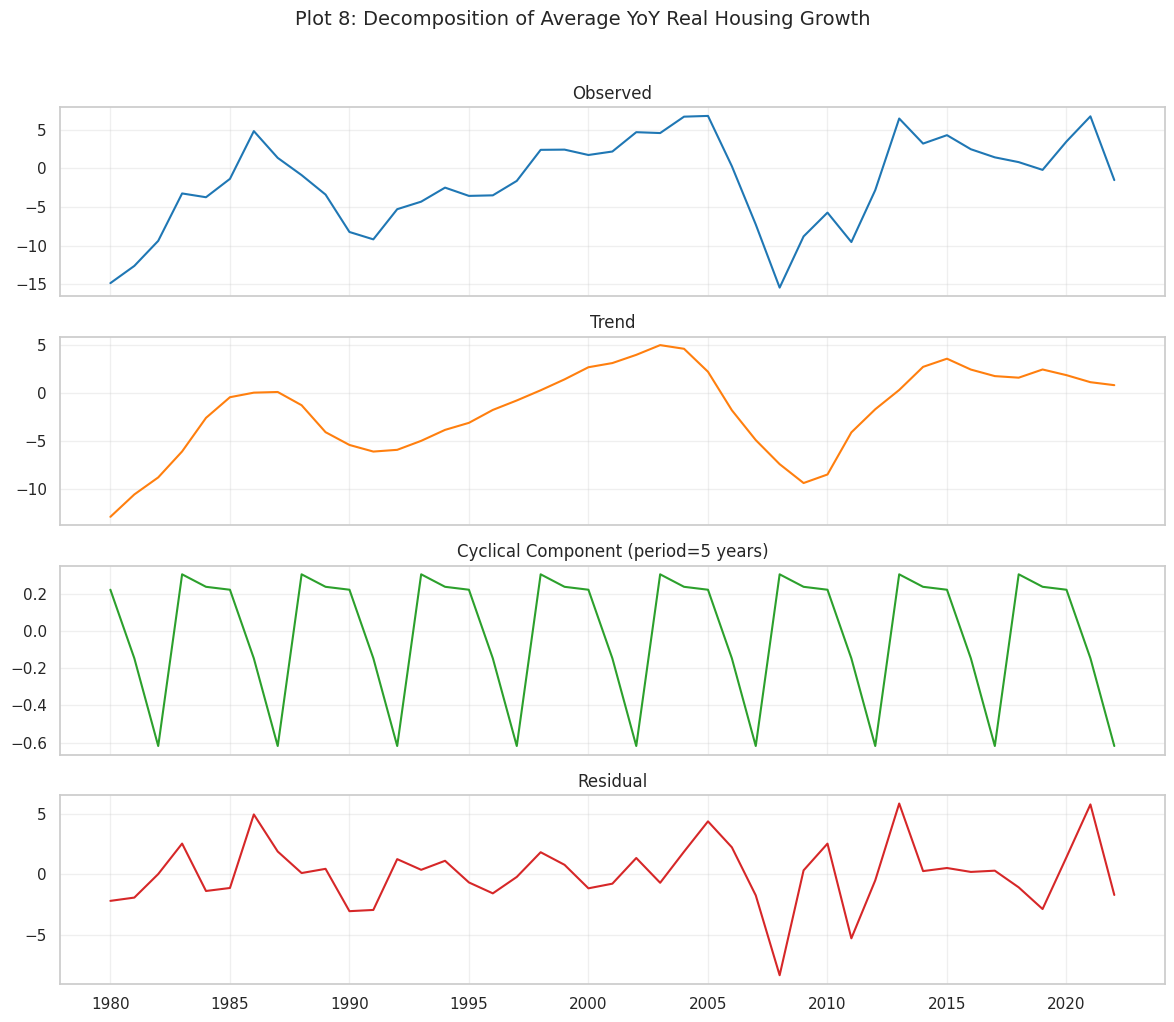

In [9]:
series = annual.set_index('year')['yoy_real'].asfreq('YS')
decomp = seasonal_decompose(series, model='additive', period=5, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(decomp.observed, color='tab:blue')
axes[0].set_title('Observed')
axes[1].plot(decomp.trend, color='tab:orange')
axes[1].set_title('Trend')
axes[2].plot(decomp.seasonal, color='tab:green')
axes[2].set_title('Cyclical Component (period=5 years)')
axes[3].plot(decomp.resid, color='tab:red')
axes[3].set_title('Residual')

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle('Plot 8: Decomposition of Average YoY Real Housing Growth', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'M2_plot8_time_series_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** The decomposition shows a clear low-frequency trend with cyclical swings and non-white residual structure around major macro shocks. M3 should include year fixed effects (or time controls) and robust standard errors.

## M3 Modeling Implications
1. Include mortgage-rate terms (current and short lag) due to strong negative associations with housing growth.
2. Include region interaction terms (Region $\times$ Mortgage Rate; Region $\times$ Disaster Exposure) to capture heterogeneous sensitivity.
3. Include macro controls and time effects to account for broad economic cycles and reduce omitted-variable bias.